In [ ]:
# ============================================================
#  DOWNLOAD DATASET
# ============================================================
import kagglehub

path = kagglehub.dataset_download("niteshfre/chessman-image-dataset")
print("Path to dataset files:", path)

100%|██████████| 57.6M/57.6M [00:04<00:00, 13.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1


In [ ]:
# ============================================================
#  Imports & Config
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, MobileNet, Xception
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

IMG_SIZE   = 96
BATCH_SIZE = 32
EPOCHS     = 20
SEED       = 42
SAVE_DIR   = '/content/models'
os.makedirs(SAVE_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
#  Find Image Directory
# ============================================================
for root, dirs, files in os.walk(path):
    print(f"DIR: {root}")
    print(f"  subdirs: {dirs}")
    print(f"  files  : {files[:5]}")
    print()

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1
  subdirs: ['Chessman-image-dataset']
  files  : []

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1/Chessman-image-dataset
  subdirs: ['Chess']
  files  : []

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1/Chessman-image-dataset/Chess
  subdirs: ['King', 'Queen', 'Knight', 'Bishop', 'Rook', 'Pawn']
  files  : []

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1/Chessman-image-dataset/Chess/King
  subdirs: []
  files  : ['00000004.jpg', '00000012.jpg', '00000007.jpg', '00000037.jpg', '00000058.jpg']

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1/Chessman-image-dataset/Chess/Queen
  subdirs: []
  files  : ['00000081.jpg', '00000059.jpg', '00000012.jpg', '00000076.png', '00000007.jpg']

DIR: /root/.cache/kagglehub/datasets/niteshfre/chessman-image-dataset/versions/1/Chessman-i

In [ ]:
images, labels = [], []

# Directly set IMAGE_DIR based on inspection of CELL 4 output
IMAGE_DIR = os.path.join(path, 'Chessman-image-dataset', 'Chess')

class_names = sorted([
    d for d in os.listdir(IMAGE_DIR)
    if os.path.isdir(os.path.join(IMAGE_DIR, d)) and not d.startswith('.')
])

for idx, cls in enumerate(class_names):
    cls_path = os.path.join(IMAGE_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = load_img(os.path.join(cls_path, fname), target_size=(IMG_SIZE, IMG_SIZE))
                images.append(img_to_array(img))
                labels.append(idx)
            except:
                pass

X = np.array(images, dtype='float32')
y = np.array(labels)
NUM_CLASSES = len(class_names)

print(f"Images : {X.shape}")
print(f"Classes: {NUM_CLASSES} → {class_names}")

Images : (551, 96, 96, 3)
Classes: 6 → ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']


In [ ]:
# ============================================================
#   Train / Val / Test Split
# ============================================================
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=SEED)

X_train_n = X_train / 255.0
X_val_n   = X_val   / 255.0
X_test_n  = X_test  / 255.0

y_train_cat = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (397, 96, 96, 3) | Val: (71, 96, 96, 3) | Test: (83, 96, 96, 3)


In [ ]:
# ============================================================
# Shared Utilities
# ============================================================
results = {}

def get_augmentation():
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        zoom_range=0.15,
        fill_mode='nearest'
    )

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=0),
        ModelCheckpoint(f'{SAVE_DIR}/{name}.h5', save_best_only=True, monitor='val_accuracy', verbose=0)
    ]

def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{name} — Training History', fontweight='bold')
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val', linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history.history['loss'], label='Train', color='orange')
    axes[1].plot(history.history['val_loss'], label='Val', linestyle='--', color='red')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_model(model, Xte, yte_cat, yte_raw, name, t):
    loss, acc = model.evaluate(Xte, yte_cat, verbose=0)
    y_pred = np.argmax(model.predict(Xte, verbose=0), axis=1)
    print(f"\n{name} → Accuracy: {acc*100:.2f}% | Loss: {loss:.4f} | Time: {t:.1f}s | Params: {model.count_params():,}")
    cm = confusion_matrix(yte_raw, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{name} — Confusion Matrix', fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    results[name] = {'accuracy': acc, 'loss': loss, 'time': t, 'params': model.count_params()}

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.2607 - loss: 2.3570

13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3275 - loss: 2.1023 - val_accuracy: 0.4648 - val_loss: 2.2057 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5214 - loss: 1.4734 - val_accuracy: 0.4648 - val_loss: 2.4286 - learning_rate: 0.0010
Epoch 3/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5310 - loss: 1.2926

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.5516 - loss: 1.2304 - val_accuracy: 0.5915 - val_loss: 1.9038 - learning_rate: 0.0010
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.6348 - loss: 0.9929 - val_accuracy: 0.5493 - val_loss: 2.0891 - learning_rate: 0.0010
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6776 - loss: 0.9581 - val_accuracy: 0.5493 - val_loss: 1.7973 - learning_rate: 0.0010
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.7103 - loss: 0.8079 - val_accuracy: 0.5634 - val_loss: 1.7994 - learning_rate: 0.0010
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7154 - loss: 0.7915 - val_accuracy: 0.5634 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.6725 - loss: 0.8514 - val_accuracy: 0.5775 - val_loss: 1.6264 - learning_rate: 0.0010
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.7330 - loss: 0.7855 - val_accuracy:

13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.5139 - loss: 1.4662 - val_accuracy: 0.5493 - val_loss: 1.8500 - learning_rate: 1.0000e-05
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5324 - loss: 1.3073

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.5441 - loss: 1.3176 - val_accuracy: 0.5634 - val_loss: 1.7910 - learning_rate: 1.0000e-05
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.5113 - loss: 1.3298 - val_accuracy: 0.5352 - val_loss: 1.7359 - learning_rate: 1.0000e-05
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.5542 - loss: 1.2340 - val_accuracy: 0.5352 - val_loss: 1.6863 - learning_rate: 1.0000e-05
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5390 - loss: 1.3076 - val_accuracy: 0.5352 - val_loss: 1.6574 - learning_rate: 1.0000e-05
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.5919 - loss: 1.2049 - val_accuracy: 0.5493 - val_loss: 1.6191 - learning_rate: 1.0000e-05
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5844 - loss: 1.2084 - val_accuracy: 0.5493 - val_loss: 1.5737 - learning_rate: 1.0000e-05
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.5214 - loss:

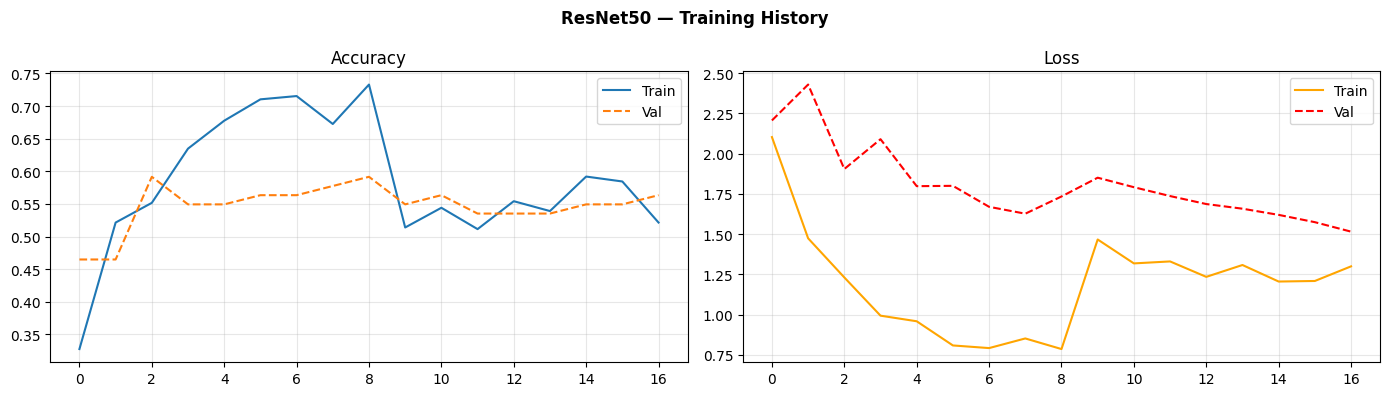


ResNet50 → Accuracy: 51.81% | Loss: 1.6715 | Time: 100.8s | Params: 24,771,718


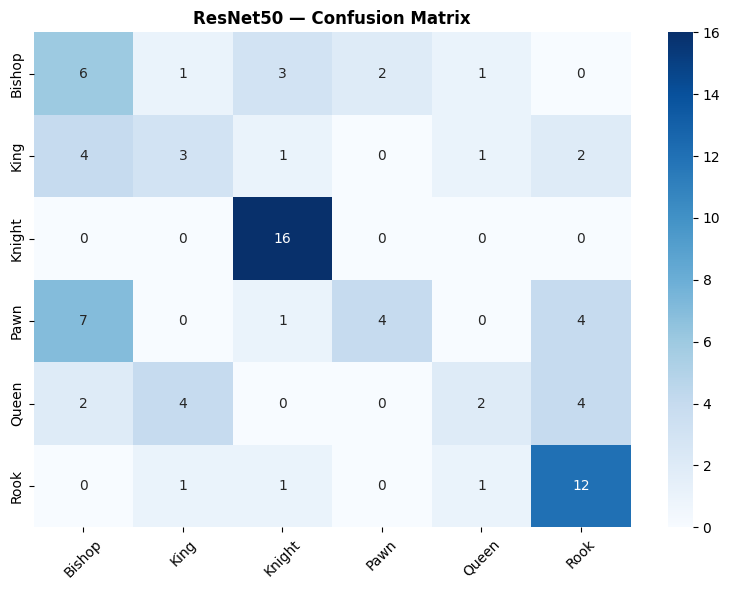

In [ ]:
# ============================================================
#   ResNet50
# ============================================================
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre

def unfreeze_resnet(base):
    base.trainable = True
    for layer in base.layers:
        if 'conv5' not in layer.name:
            layer.trainable = False

model_resnet = train_transfer(ResNet50, resnet_pre, 'ResNet50', unfreeze_resnet)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.1948 - loss: 2.6722

13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.2569 - loss: 2.4111 - val_accuracy: 0.3944 - val_loss: 1.8202 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5281 - loss: 1.4859

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5013 - loss: 1.4882 - val_accuracy: 0.4930 - val_loss: 1.6491 - learning_rate: 0.0010
Epoch 3/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5499 - loss: 1.2645

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.5844 - loss: 1.1861 - val_accuracy: 0.5634 - val_loss: 1.6070 - learning_rate: 0.0010
Epoch 4/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6534 - loss: 0.8525

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6549 - loss: 0.8965 - val_accuracy: 0.6056 - val_loss: 1.5668 - learning_rate: 0.0010
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.6826 - loss: 0.8924 - val_accuracy: 0.6056 - val_loss: 1.4014 - learning_rate: 0.0010
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7229 - loss: 0.7794 - val_accuracy: 0.6056 - val_loss: 1.2158 - learning_rate: 0.0010
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6948 - loss: 0.8138

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6977 - loss: 0.8262 - val_accuracy: 0.7042 - val_loss: 1.1501 - learning_rate: 0.0010
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7380 - loss: 0.7572 - val_accuracy: 0.6761 - val_loss: 1.1783 - learning_rate: 0.0010
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7909 - loss: 0.6074 - val_accuracy: 0.7042 - val_loss: 1.1095 - learning_rate: 0.0010
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7355 - loss: 0.7363 - val_accuracy: 0.6338 - val_loss: 1.0653 - learning_rate: 0.0010
Epoch 1/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.5891 - loss: 1.2548

13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5542 - loss: 1.3464 - val_accuracy: 0.6901 - val_loss: 1.1176 - learning_rate: 1.0000e-05
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5340 - loss: 1.3731 - val_accuracy: 0.6761 - val_loss: 1.0905 - learning_rate: 1.0000e-05
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.5567 - loss: 1.2211 - val_accuracy: 0.6479 - val_loss: 1.0882 - learning_rate: 1.0000e-05
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5491 - loss: 1.3188 - val_accuracy: 0.6197 - val_loss: 1.0873 - learning_rate: 1.0000e-05
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5693 - loss: 1.2920 - val_accuracy: 0.6197 - val_loss: 1.0862 - learning_rate: 1.0000e-05
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5416 - loss: 1.3479 - val_accuracy: 0.6197 - val_loss: 1.0887 - learning_rate: 1.0000e-05
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5315 - loss: 1.2

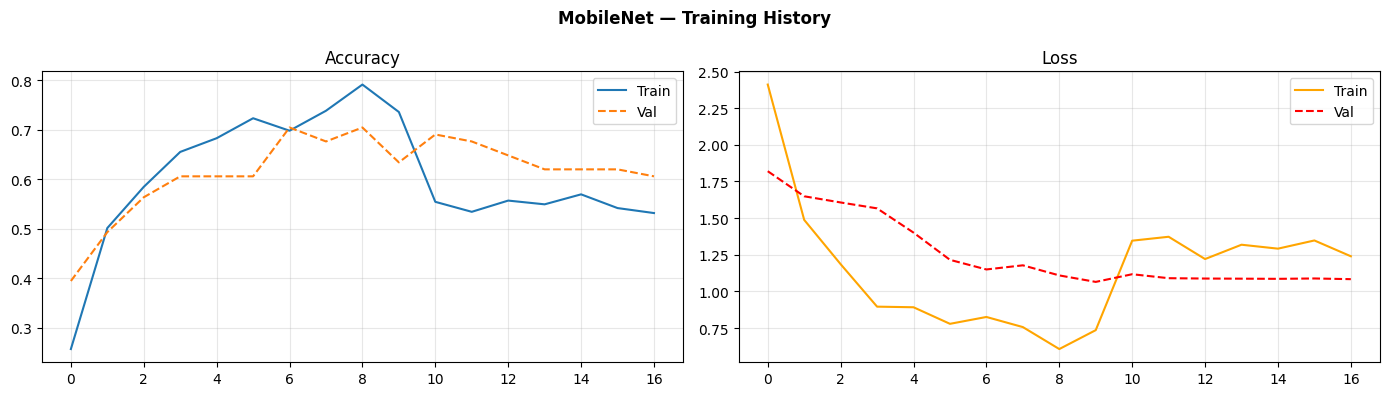


MobileNet → Accuracy: 63.86% | Loss: 1.1621 | Time: 94.9s | Params: 3,888,582


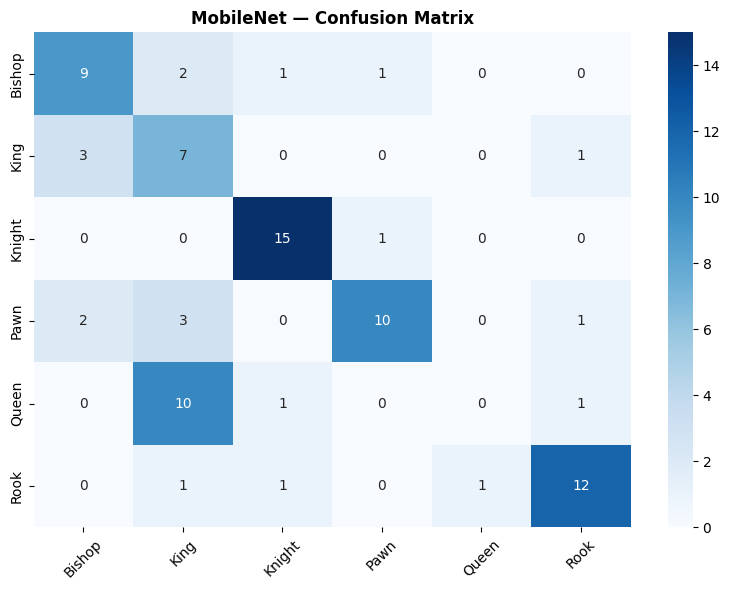

In [ ]:
# ============================================================
#  MODEL 6: MobileNet
# ============================================================
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_pre

def unfreeze_mobilenet(base):
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

model_mob = train_transfer(MobileNet, mob_pre, 'MobileNet', unfreeze_mobilenet)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2809 - loss: 2.5172

13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.2897 - loss: 2.4051 - val_accuracy: 0.3099 - val_loss: 1.8850 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3978 - loss: 1.6633

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.4131 - loss: 1.6884 - val_accuracy: 0.4085 - val_loss: 1.7017 - learning_rate: 0.0010
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4710 - loss: 1.5501 - val_accuracy: 0.3944 - val_loss: 1.7726 - learning_rate: 0.0010
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5013 - loss: 1.3692 - val_accuracy: 0.3803 - val_loss: 1.5415 - learning_rate: 0.0010
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5165 - loss: 1.3056

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.5315 - loss: 1.2725 - val_accuracy: 0.4930 - val_loss: 1.7401 - learning_rate: 0.0010
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5531 - loss: 1.4051

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 160ms/step - accuracy: 0.5290 - loss: 1.4068 - val_accuracy: 0.5211 - val_loss: 1.4077 - learning_rate: 0.0010
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.5819 - loss: 1.1540 - val_accuracy: 0.5070 - val_loss: 1.3583 - learning_rate: 0.0010
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.5869 - loss: 1.1370 - val_accuracy: 0.4225 - val_loss: 1.5094 - learning_rate: 0.0010
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6071 - loss: 1.0483 - val_accuracy: 0.5211 - val_loss: 1.3696 - learning_rate: 0.0010
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.6045 - loss: 1.1630 - val_accuracy: 0.4507 - val_loss: 1.4807 - learning_rate: 0.0010
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.3509 - loss: 1.7157

13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.3627 - loss: 1.7280 - val_accuracy: 0.5070 - val_loss: 1.3246 - learning_rate: 1.0000e-05
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.4156 - loss: 1.5796 - val_accuracy: 0.4789 - val_loss: 1.2948 - learning_rate: 1.0000e-05
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4786 - loss: 1.4843 - val_accuracy: 0.4930 - val_loss: 1.2881 - learning_rate: 1.0000e-05
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.4282 - loss: 1.5497 - val_accuracy: 0.4930 - val_loss: 1.2902 - learning_rate: 1.0000e-05
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.4207 - loss: 1.4798 - val_accuracy: 0.4930 - val_loss: 1.2941 - learning_rate: 1.0000e-05
Epoch 6/10
12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4248 - loss: 1.4866

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.4358 - loss: 1.4911 - val_accuracy: 0.5352 - val_loss: 1.3014 - learning_rate: 1.0000e-05
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.4534 - loss: 1.5307 - val_accuracy: 0.5352 - val_loss: 1.3085 - learning_rate: 5.0000e-06
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.4408 - loss: 1.5645 - val_accuracy: 0.5352 - val_loss: 1.3130 - learning_rate: 5.0000e-06
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.4534 - loss: 1.5041 - val_accuracy: 0.5352 - val_loss: 1.3130 - learning_rate: 5.0000e-06
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.4912 - loss: 1.4313 - val_accuracy: 0.5352 - val_loss: 1.3101 - learning_rate: 2.5000e-06


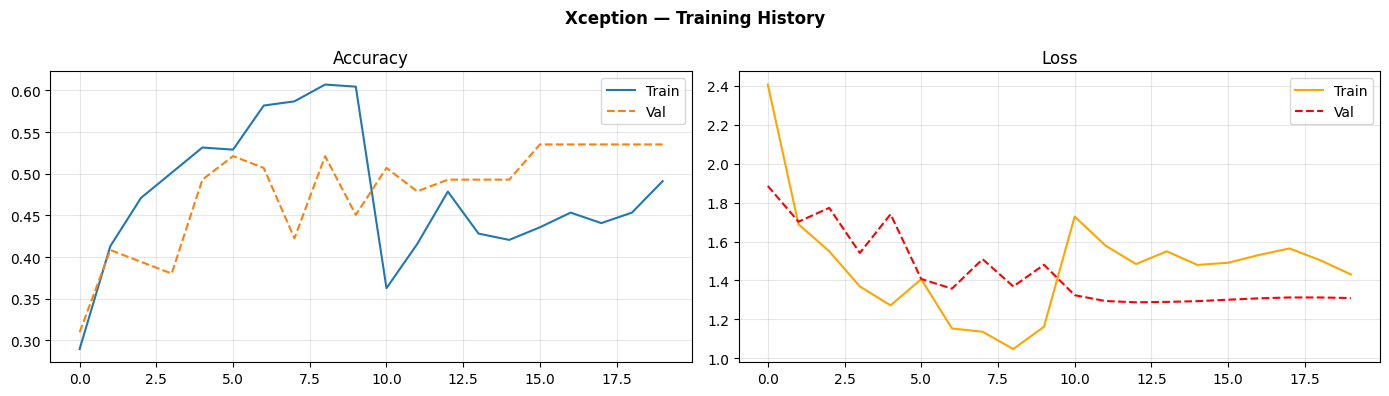


Xception → Accuracy: 50.60% | Loss: 1.3933 | Time: 113.6s | Params: 22,045,486


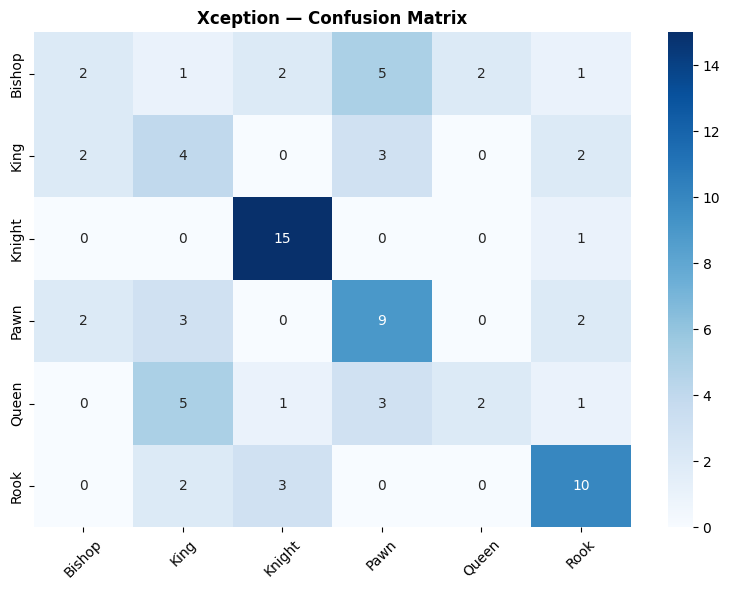

In [ ]:
# ============================================================
#  MODEL 7: Xception
# ============================================================
from tensorflow.keras.applications.xception import preprocess_input as xc_pre

def unfreeze_xception(base):
    base.trainable = True
    for layer in base.layers:
        if 'block13' not in layer.name and 'block14' not in layer.name:
            layer.trainable = False

model_xc = train_transfer(Xception, xc_pre, 'Xception', unfreeze_xception)

        Model  Accuracy (%)    Loss  Time (s)  Params (M)
1       VGG16         73.49  0.6854      68.9       15.11
2       VGG19         69.88  1.2933      52.5       20.42
3   MobileNet         63.86  1.1621      94.9        3.89
4    ResNet50         51.81  1.6715     100.8       24.77
5    Xception         50.60  1.3933     113.6       22.05
6     AlexNet         19.28  1.7925      72.1      171.13
7  Custom CNN         19.28  1.9998      51.5        5.31


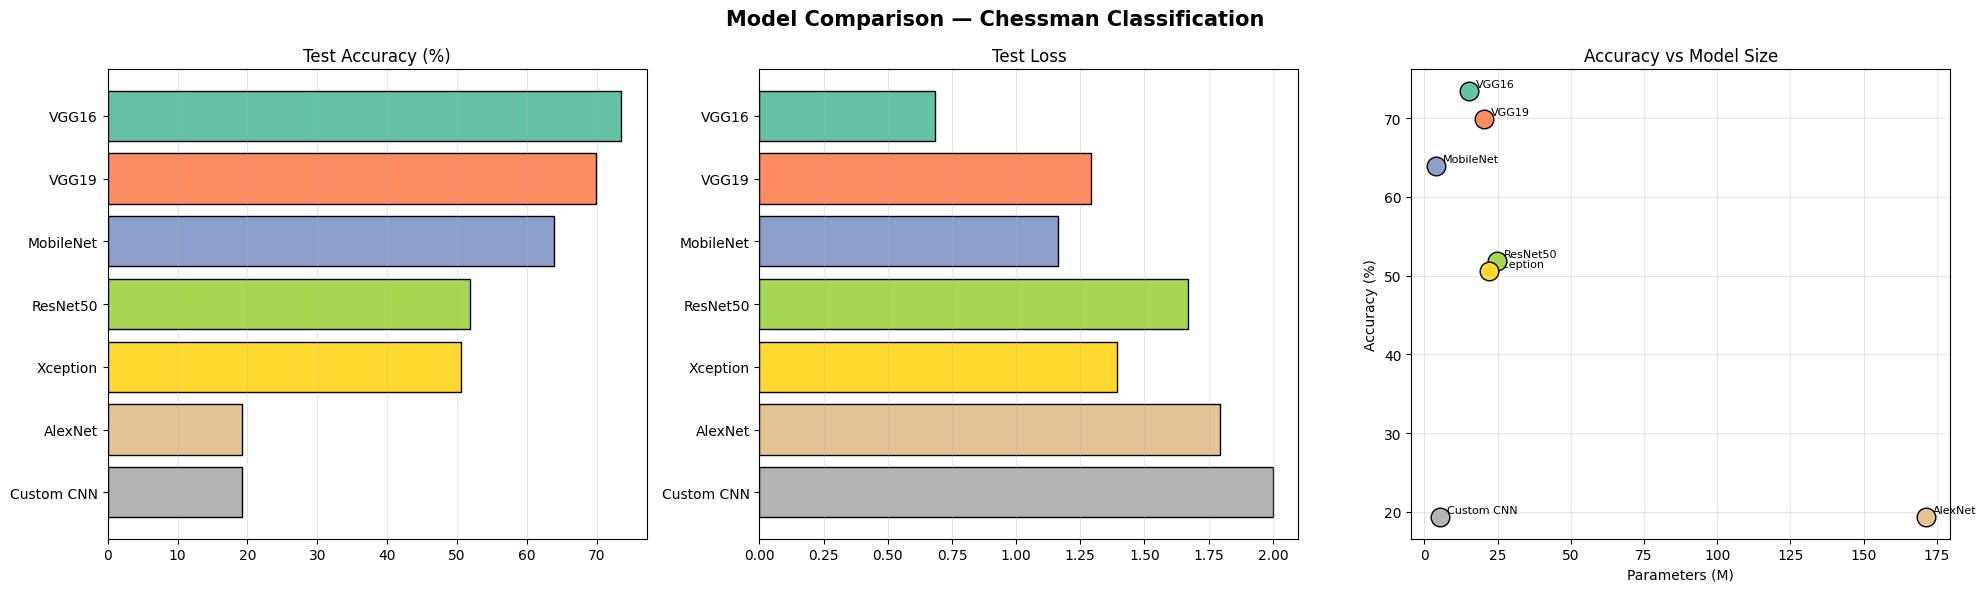

Saved: /content/results.csv and /content/comparison.png


In [ ]:
# ============================================================
#  Final Leaderboard & Comparison
# ============================================================
df_res = pd.DataFrame([
    {
        'Model': k,
        'Accuracy (%)': round(v['accuracy'] * 100, 2),
        'Loss': round(v['loss'], 4),
        'Time (s)': round(v['time'], 1),
        'Params (M)': round(v['params'] / 1e6, 2)
    }
    for k, v in results.items()
]).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
df_res.index += 1
print(df_res.to_string())

colors = plt.cm.Set2(np.linspace(0, 1, len(df_res)))
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison — Chessman Classification', fontsize=15, fontweight='bold')

axes[0].barh(df_res['Model'], df_res['Accuracy (%)'], color=colors, edgecolor='black')
axes[0].set_title('Test Accuracy (%)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(df_res['Model'], df_res['Loss'], color=colors, edgecolor='black')
axes[1].set_title('Test Loss')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

for i, row in df_res.iterrows():
    axes[2].scatter(row['Params (M)'], row['Accuracy (%)'], s=180, color=colors[i-1], edgecolor='black', zorder=5)
    axes[2].annotate(row['Model'], (row['Params (M)'], row['Accuracy (%)']), xytext=(5, 3), textcoords='offset points', fontsize=8)
axes[2].set_xlabel('Parameters (M)')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Accuracy vs Model Size')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/comparison.png', dpi=150, bbox_inches='tight')
plt.show()

df_res.to_csv('/content/results.csv', index=False)
print("Saved: /content/results.csv and /content/comparison.png")